LOADING THE DATASET

In [ ]:
import pandas as pd
df=pd.read_csv('/content/imbalanced-data.csv')
df.head(5)

,rating,review
0,5,love the pockets and back of dress the buttons...
1,5,delivered on time easy to fit to my mums hands...
2,5,tried this on just for fun today and ended up ...
3,1,before ordering a new oven i asked teamknowhow...
4,5,great hotel centrally located just came night ...


In [ ]:
df['rating'].value_counts()

,count
rating,
5,82276
1,20512
4,19326
3,7349
2,3654


In [ ]:
import pandas as pd

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Desired sample sizes based on % targets
target_counts = {
    1: 2436,
    2: 3654,
    3: 4872,
    4: 6090,
    5: 7308
}

# Apply sampling
sampled = []

for rating, count in target_counts.items():
    group = df[df['rating'] == rating]
    sampled.append(group.iloc[:count])  # get top N

final_df = pd.concat(sampled).reset_index(drop=True)

# Check result
print(final_df['rating'].value_counts(normalize=True) * 100)  # % distribution


rating
5    30.0
4    25.0
3    20.0
2    15.0
1    10.0
Name: proportion, dtype: float64


In [ ]:
final_df.to_csv('imbalanc-dataset.csv',index=False)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
final_df=pd.read_csv('/content/imbalance-dataset.csv')

PIE CHART

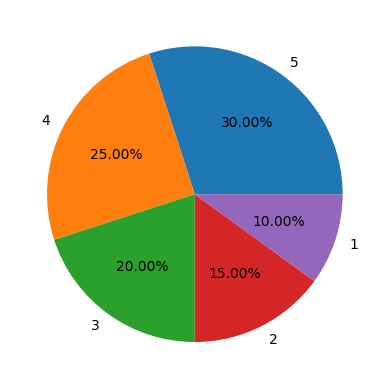

In [ ]:
import matplotlib.pyplot as plt
plt.pie(final_df['rating'].value_counts(),labels=final_df['rating'].value_counts().index,autopct='%1.2f%%')
plt.show()

In [ ]:
final_df['rating'].value_counts()

,count
rating,
5,7308
4,6090
3,4872
2,3654
1,2436


In [ ]:
final_df['review']=final_df['review'].astype(str).str.lower()

In [ ]:
final_df.shape

(24360, 2)

REMOVING STOPWORDS

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = word_tokenize(str(text))  # tokenize text
    filtered = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered)
final_df['review']=final_df['review'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
stop_words = set(stopwords.words('english'))

# Display total count and all stopwords
print("Total stopwords:", len(stop_words))
print(sorted(stop_words))  # Sorted alphabetically

Total stopwords: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", "he's", 'her', 'here', 'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', "i'd", "i'll", "i'm", "i've", 'if', 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', '

In [ ]:
# Number of reviews to show per rating
n = 5

# Loop through ratings from 1 to 5
for rating in range(1, 6):
    # Filter reviews of the current rating
    filtered_reviews = final_df[final_df['rating'] == rating]['review'].dropna()

    # Sample 'n' reviews or all if fewer
    sample_reviews = filtered_reviews.sample(n=min(n, len(filtered_reviews)), random_state=rating)

    # Print the results
    print(f"\nShowing {min(n, len(filtered_reviews))} sample review(s) for Rating {rating}:\n")
    for i, review in enumerate(sample_reviews, 1):
        print(f"{i}. {review.strip()}\n")



Showing 5 sample review(s) for Rating 1:

1. im annoyed current contract finishes th jan placed order iphone mini th dec deal available th dec hard credit check performed order accepted delivery stated th jan rang monday th update knew people already received told ok still due de delivered th even checked another colour available could get sooner unfortunately wasnt continued wait two days later th jan recieved email say cancelled order due pricing error weeks ordering decide pricing error acceptable purchased new accessories iphone excited owing first apple iphone phoned customer service told send email complaint despite another customer phoning beforehand receiving compensation know number people ordered iphone contract received phones customer service dealing customers unfairly according acceptance email issues contacted discuss options instead decided cancel order would recommend hi jim im facebook twitter

2. terrible streaming service subbed watch house dragon game thrones despi

LEMMATIZATION

In [ ]:
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
lemmatizer = WordNetLemmatizer()
def lemmatize_text(text):
    words = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized)
final_df['review']=final_df['review'].apply(lemmatize_text)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
# Number of reviews to show per rating
n = 5

# Loop through ratings from 1 to 5
for rating in range(1, 6):
    # Filter reviews of the current rating
    filtered_reviews = final_df[final_df['rating'] == rating]['review'].dropna()

    # Sample 'n' reviews or all if fewer
    sample_reviews = filtered_reviews.sample(n=min(n, len(filtered_reviews)), random_state=rating)

    # Print the results
    print(f"\nShowing {min(n, len(filtered_reviews))} sample review(s) for Rating {rating}:\n")
    for i, review in enumerate(sample_reviews, 1):
        print(f"{i}. {review.strip()}\n")



Showing 5 sample review(s) for Rating 1:

1. im annoyed current contract finish th jan placed order iphone mini th dec deal available th dec hard credit check performed order accepted delivery stated th jan rang monday th update knew people already received told ok still due de delivered th even checked another colour available could get sooner unfortunately wasnt continued wait two day later th jan recieved email say cancelled order due pricing error week ordering decide pricing error acceptable purchased new accessory iphone excited owing first apple iphone phoned customer service told send email complaint despite another customer phoning beforehand receiving compensation know number people ordered iphone contract received phone customer service dealing customer unfairly according acceptance email issue contacted discus option instead decided cancel order would recommend hi jim im facebook twitter

2. terrible streaming service subbed watch house dragon game throne despite paying su

In [ ]:
short_counts = final_df[final_df['review'].apply(lambda x: len(str(x).split()) < 3)] \
                .groupby('rating').size().reset_index(name='count_less_than_3_words')

print(short_counts)
long_counts = final_df[final_df['review'].apply(lambda x: len(str(x).split()) > 150)] \
               .groupby('rating').size().reset_index(name='count_long_reviews')

print(long_counts)


   rating  count_less_than_3_words
0       1                        6
1       2                        6
2       3                       68
3       4                       89
4       5                      113
   rating  count_long_reviews
0       1                 132
1       2                 425
2       3                 327
3       4                 363
4       5                 130


In [ ]:
# Create a word count column (but don't modify the dataset permanently)
word_stats = (
    final_df.assign(word_count=final_df['review'].str.split().apply(len))
      .groupby('rating')['word_count']
      .agg(['min', 'max'])
      .reset_index()
)

print(word_stats)


   rating  min   max
0       1    1   738
1       2    1  1029
2       3    1  1861
3       4    0  1330
4       5    1  1654


TRAIN TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split
x=final_df['review']
y=final_df['rating']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)


TF-IDF VECTORIZER

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_train = vectorizer.fit_transform(x_train)
X_test = vectorizer.transform(x_test)


SVM(SUPPORT VECTOR MACHINE)

Accuracy: 0.5388509795289457

Classification Report:
               precision    recall  f1-score   support

           1       0.60      0.74      0.66       460
           2       0.47      0.47      0.47       644
           3       0.42      0.39      0.41       900
           4       0.46      0.41      0.43      1130
           5       0.67      0.70      0.68      1409

    accuracy                           0.54      4543
   macro avg       0.52      0.54      0.53      4543
weighted avg       0.53      0.54      0.53      4543



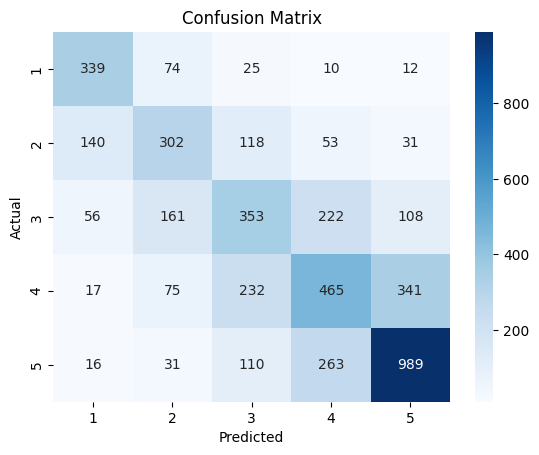

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train SVM

model = LinearSVC(C=1.0, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)


# Predictions & Evaluation

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(set(y_test)),
            yticklabels=sorted(set(y_test)))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


LOGISTIC REGRESSION

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.5665859564164649

Classification Report:
               precision    recall  f1-score   support

           1       0.59      0.77      0.67       460
           2       0.49      0.53      0.51       644
           3       0.45      0.41      0.43       900
           4       0.50      0.47      0.48      1130
           5       0.72      0.69      0.71      1409

    accuracy                           0.57      4543
   macro avg       0.55      0.58      0.56      4543
weighted avg       0.56      0.57      0.56      4543



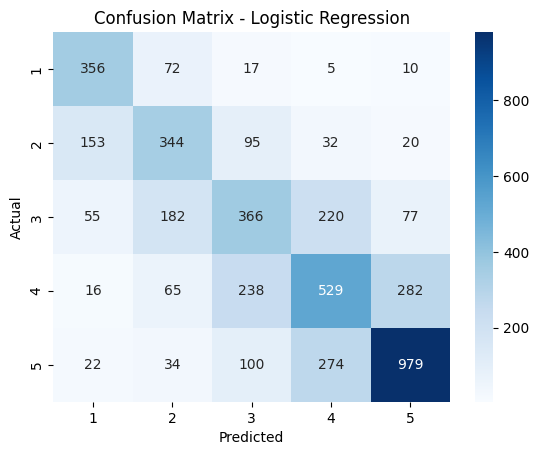

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier


# Predictions & Evaluation
y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(set(y_test)),
            yticklabels=sorted(set(y_test)))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


RANDOM FOREST

Accuracy: 0.5399515738498789

Classification Report:
               precision    recall  f1-score   support

           1       0.58      0.77      0.66       460
           2       0.56      0.41      0.47       644
           3       0.47      0.25      0.32       900
           4       0.46      0.49      0.47      1130
           5       0.60      0.75      0.67      1409

    accuracy                           0.54      4543
   macro avg       0.53      0.53      0.52      4543
weighted avg       0.53      0.54      0.52      4543



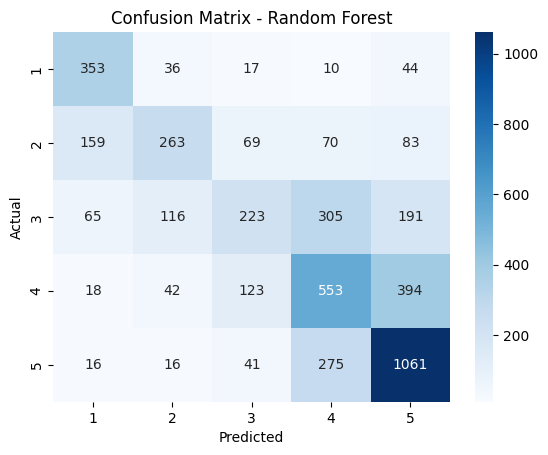

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,      # number of trees
    max_depth=None,        # None means nodes are expanded until all leaves are pure
    class_weight='balanced', # handle class imbalance
    random_state=42
)
rf_model.fit(X_train, y_train)

# Predictions & Evaluation
y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(set(y_test)),
            yticklabels=sorted(set(y_test)))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()


COMPARING

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Define models to compare
models = {
    "Logistic Regression": LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', solver='lbfgs', multi_class='auto'
    ),
    "SVM": SVC(
        kernel='linear', class_weight='balanced', probability=True, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42
    )
}

# DataFrame to store results
results = []

# Loop through models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": report["macro avg"]["precision"],
        "Recall": report["macro avg"]["recall"],
        "F1-Score ": report["macro avg"]["f1-score"]
    })

# Convert to DataFrame for better display
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print(results_df)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


                 Model  Accuracy  Precision    Recall  F1-Score 
0  Logistic Regression  0.553161   0.544649  0.576902   0.556255
1                  SVM  0.545156   0.539265  0.569760   0.550231
2        Random Forest  0.519294   0.519427  0.519479   0.500885


HYPERPARAMETER TUNING

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Parameter grid
log_params = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"],
    "class_weight": [None, "balanced"]
}

# Grid search
log_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, multi_class='auto'),
    log_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# Fit
log_grid.fit(X_train, y_train)

# Results
print("Best Logistic Regression Params:", log_grid.best_params_)
print("Best Logistic Regression Accuracy:", log_grid.best_score_)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best Logistic Regression Params: {'C': 1, 'class_weight': None, 'solver': 'liblinear'}
Best Logistic Regression Accuracy: 0.5540845648604269


SAVE THE MODEL

In [ ]:
import joblib


# Save models
joblib.dump(sgd_model, "Model_B3.pkl")

# Also save the TF-IDF vectorizer
joblib.dump(vectorizer, "vectorizer23.pkl")


['vectorizer23.pkl']

MODEL A IN IMBALANCED TEST DATASET

Accuracy: 0.4139983579638752

Classification Report:
               precision    recall  f1-score   support

           1       0.32      0.81      0.46       487
           2       0.29      0.27      0.28       731
           3       0.38      0.20      0.26       974
           4       0.40      0.31      0.35      1218
           5       0.56      0.59      0.57      1462

    accuracy                           0.41      4872
   macro avg       0.39      0.43      0.38      4872
weighted avg       0.42      0.41      0.40      4872



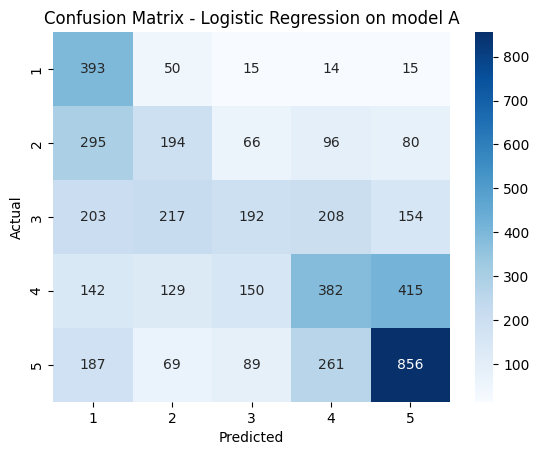

In [ ]:
log_model = joblib.load("Model_A.pkl")
vectorizer = joblib.load("vectorizer.pkl") # Load the vectorizer

# Transform X_test using the loaded vectorizer
X_test_transformed = vectorizer.transform(x_test)

# Predictions & Evaluation
y_pred = log_model.predict(X_test_transformed)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(set(y_test)),
            yticklabels=sorted(set(y_test)))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression on model A")
plt.show()